In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost --quiet
print('All packages installed!')

All packages installed!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8-darkgrid')
print('Libraries imported successfully!')

Libraries imported successfully!


In [10]:
import pandas as pd

df = pd.read_csv(r"C:\Users\aman\OneDrive\Desktop\Mutual_fund Data.csv")

print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
df.head()

Shape   : (1393, 13)
Columns : ['AMC', 'Fund Name', 'Morning star rating', 'Value Research rating', '1 month return', 'NAV', '1 Year return', '3 Year Return', 'Minimum investment', 'Fund Manager', 'AUM', 'Category', 'Risk']


,AMC,Fund Name,Morning star rating,Value Research rating,1 month return,NAV,1 Year return,3 Year Return,Minimum investment,Fund Manager,AUM,Category,Risk
0,mahindra manulife mutual fund,Mahindra Manulife Large & Mid Cap Reg-G,3,3,5.51%,28.32,37.79%,20.29%,Rs.500.0,Abhinav Khandelwal,2569.63 cr,Equity,High
1,mahindra manulife mutual fund,Mahindra Manulife Consumption Reg-G,0,3,7.25%,24.89,46.08%,21.93%,Rs.500.0,Abhinav Khandelwal,322.26 cr,Equity,High
2,mahindra manulife mutual fund,Mahindra Manulife Mid Cap Reg-G,4,4,5.94%,35.11,54.46%,27.48%,Rs.500.0,Abhinav Khandelwal,3292.76 cr,Equity,High
3,mahindra manulife mutual fund,Mahindra Manulife Small Cap Reg-G,0,0,8.37%,21.40,59.79%,0,Rs.500.0,Abhinav Khandelwal,5278.7 cr,Equity,Very High
4,mahindra manulife mutual fund,Mahindra Manulife Large Cap Reg-G,4,3,4.06%,23.69,32.07%,15.18%,Rs.500.0,Abhinav Khandelwal,577.72 cr,Equity,Very High


In [11]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Data Types ===
AMC                       object
Fund Name                 object
Morning star rating        int64
Value Research rating      int64
1 month return            object
NAV                      float64
1 Year return             object
3 Year Return             object
Minimum investment        object
Fund Manager              object
AUM                       object
Category                  object
Risk                      object
dtype: object

=== Missing Values ===
AMC                       0
Fund Name                 0
Morning star rating       0
Value Research rating     0
1 month return            0
NAV                       0
1 Year return             0
3 Year Return             0
Minimum investment        0
Fund Manager             39
AUM                       0
Category                  0
Risk                      0
dtype: int64


In [12]:
def pct_to_float(series):
    return pd.to_numeric(
        series.astype(str).str.replace('%', '').str.strip(),
        errors='coerce'
    )

# ── Extract numeric AUM (crores) ──
def parse_aum(series):
    return pd.to_numeric(
        series.astype(str).str.replace(' cr', '').str.strip(),
        errors='coerce'
    )

# ── Extract numeric minimum investment ──
def parse_min_inv(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace('Rs.', '', regex=False)
              .str.replace(',', '')
              .str.strip(),
        errors='coerce'
    )

df['1_month_return'] = pct_to_float(df['1 month return'])
df['1_year_return']  = pct_to_float(df['1 Year return'])
df['3_year_return']  = pct_to_float(df['3 Year Return'])
df['AUM_cr']         = parse_aum(df['AUM'])
df['Min_Investment'] = parse_min_inv(df['Minimum investment'])

# ── Clean Risk column ──
risk_map = {
    'Low': 'Low', 'Low ': 'Low',
    'Low to Moderate': 'Low to Moderate',
    'Low toModerate ': 'Low to Moderate',
    'Moderate': 'Moderate', 'Moderate ': 'Moderate',
    'Moderately High': 'Moderately High',
    'Moderately High ': 'Moderately High',
    'High': 'High', 'High ': 'High',
    'Very High': 'Very High', 'Very High ': 'Very High',
    'Risk Level': np.nan
}
df['Risk_clean'] = df['Risk'].map(risk_map)

print('Cleaned columns added.')
df[['1_month_return','1_year_return','3_year_return',
    'AUM_cr','Min_Investment','Risk_clean']].head()

Cleaned columns added.


,1_month_return,1_year_return,3_year_return,AUM_cr,Min_Investment,Risk_clean
0,5.51,37.79,20.29,2569.63,500.0,High
1,7.25,46.08,21.93,322.26,500.0,High
2,5.94,54.46,27.48,3292.76,500.0,High
3,8.37,59.79,0.00,5278.70,500.0,Very High
4,4.06,32.07,15.18,577.72,500.0,Very High


In [13]:
df.dropna(subset=['NAV'], inplace=True)

# Fill numeric NaNs with median
for col in ['1_month_return','1_year_return','3_year_return','AUM_cr','Min_Investment']:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical NaNs
df['Risk_clean'].fillna(df['Risk_clean'].mode()[0], inplace=True)
df['Fund Manager'].fillna('Unknown', inplace=True)

print(f'Clean dataset shape: {df.shape}')
print('Remaining nulls (key cols):')
print(df[['NAV','1_month_return','1_year_return','3_year_return',
          'AUM_cr','Risk_clean']].isnull().sum())

Clean dataset shape: (1393, 19)
Remaining nulls (key cols):
NAV               0
1_month_return    0
1_year_return     0
3_year_return     0
AUM_cr            0
Risk_clean        0
dtype: int64


In [14]:
print('=== NAV Statistics ===')
df['NAV'].describe().round(2)

=== NAV Statistics ===


count    1393.00
mean      321.14
std       856.94
min         0.00
25%        15.26
50%        28.89
75%       101.32
max      6706.89
Name: NAV, dtype: float64

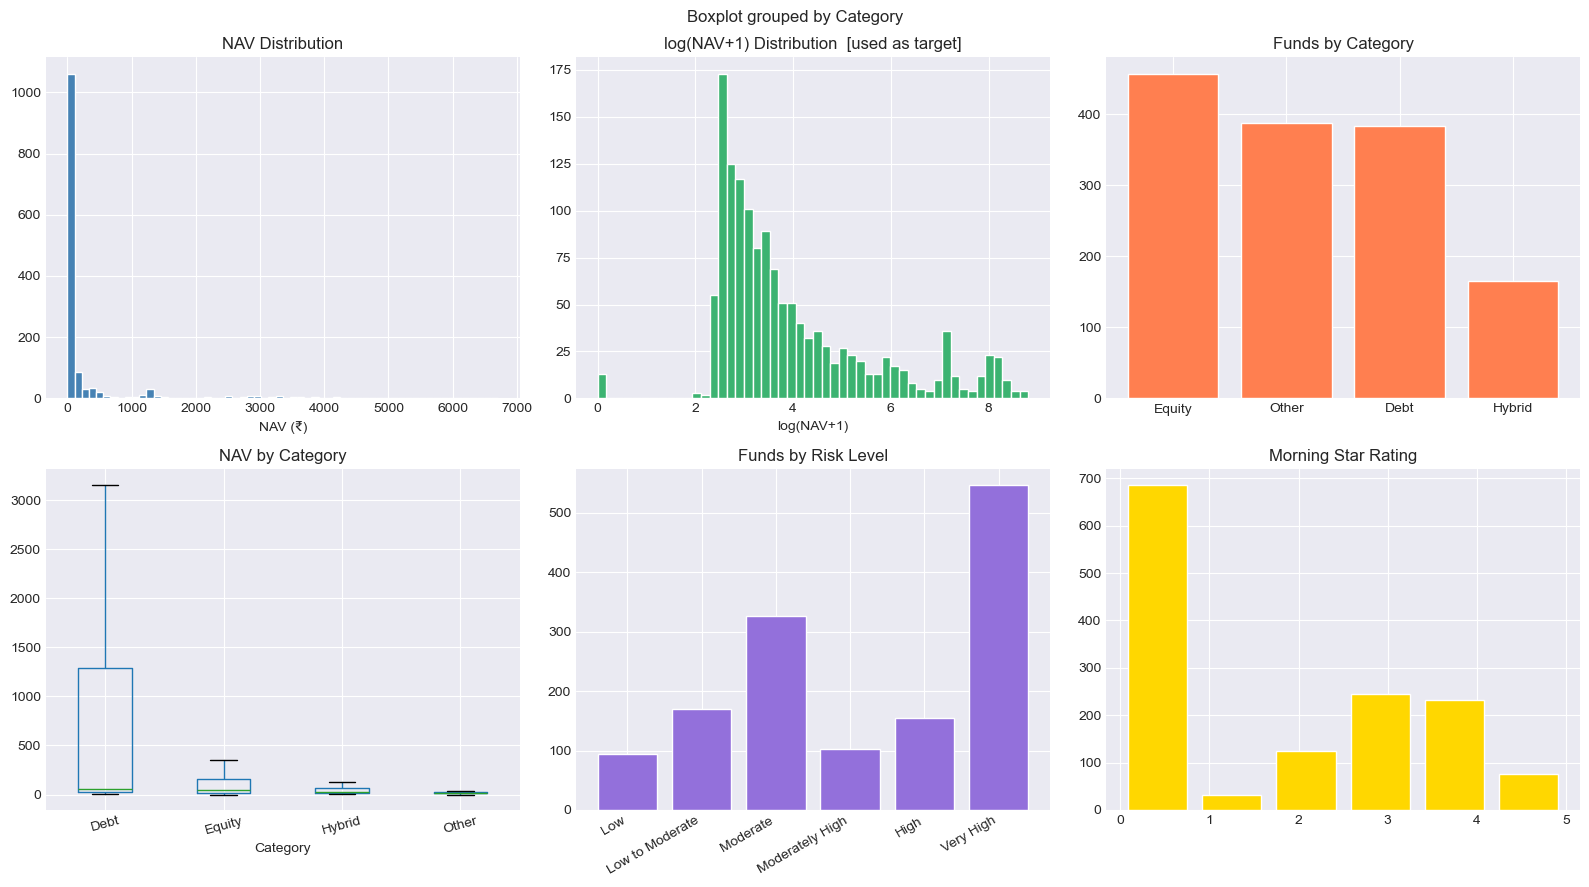

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA — Indian Mutual Fund Dataset', fontsize=15, fontweight='bold')

# NAV distribution
axes[0,0].hist(df['NAV'], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('NAV Distribution')
axes[0,0].set_xlabel('NAV (₹)')

# Log-NAV distribution
axes[0,1].hist(np.log1p(df['NAV']), bins=50, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('log(NAV+1) Distribution  [used as target]')
axes[0,1].set_xlabel('log(NAV+1)')

# Funds by Category
cat_counts = df['Category'].value_counts()
axes[0,2].bar(cat_counts.index, cat_counts.values, color='coral', edgecolor='white')
axes[0,2].set_title('Funds by Category')

# NAV by Category
df.boxplot(column='NAV', by='Category', ax=axes[1,0], showfliers=False)
axes[1,0].set_title('NAV by Category')
plt.sca(axes[1,0]); plt.xticks(rotation=15)

# Risk distribution
risk_order = ['Low','Low to Moderate','Moderate','Moderately High','High','Very High']
rc = df['Risk_clean'].value_counts().reindex(
    [r for r in risk_order if r in df['Risk_clean'].values])
axes[1,1].bar(rc.index, rc.values, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Funds by Risk Level')
plt.sca(axes[1,1]); plt.xticks(rotation=30, ha='right')

# Rating distribution
axes[1,2].hist(df['Morning star rating'], bins=6, color='gold',
               edgecolor='white', rwidth=0.8)
axes[1,2].set_title('Morning Star Rating')

plt.tight_layout()
plt.show()

In [16]:
df_model = df.copy()


risk_order_map = {
    'Low': 1, 'Low to Moderate': 2, 'Moderate': 3,
    'Moderately High': 4, 'High': 5, 'Very High': 6
}
df_model['Risk_encoded'] = df_model['Risk_clean'].map(risk_order_map).fillna(3)

# One-Hot Encoding for Category
df_model = pd.get_dummies(df_model, columns=['Category'], prefix='Cat', drop_first=True)

# Label Encoding for AMC
le_amc = LabelEncoder()
df_model['AMC_encoded'] = le_amc.fit_transform(df_model['AMC'].astype(str))

# Derived feature: Return-to-Risk ratio
df_model['Return_Risk_Ratio'] = df_model['1_year_return'] / (df_model['Risk_encoded'] + 1e-5)

# Log-transform target (NAV is heavily right-skewed)
df_model['log_NAV'] = np.log1p(df_model['NAV'])

# Final feature list
cat_dummies = [c for c in df_model.columns if c.startswith('Cat_')]
FEATURES = [
    'Morning star rating', 'Value Research rating',
    '1_month_return', '1_year_return', '3_year_return',
    'AUM_cr', 'Min_Investment',
    'Risk_encoded', 'AMC_encoded', 'Return_Risk_Ratio'
] + cat_dummies

TARGET = 'log_NAV'

print(f'Total features : {len(FEATURES)}')
print(f'Features       : {FEATURES}')

Total features : 13
Features       : ['Morning star rating', 'Value Research rating', '1_month_return', '1_year_return', '3_year_return', 'AUM_cr', 'Min_Investment', 'Risk_encoded', 'AMC_encoded', 'Return_Risk_Ratio', 'Cat_Equity', 'Cat_Hybrid', 'Cat_Other']


In [17]:
X = df_model[FEATURES].values
y = df_model[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 1114
Test samples     : 279
Features         : 13


In [18]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred_log = model.predict(X_te)

    pred_nav = np.expm1(pred_log)   # back to original NAV scale
    true_nav = np.expm1(y_te)

    mae  = mean_absolute_error(true_nav, pred_nav)
    rmse = np.sqrt(mean_squared_error(true_nav, pred_nav))
    r2   = r2_score(y_te, pred_log)
    mape = np.mean(np.abs((true_nav - pred_nav) / (true_nav + 1e-9))) * 100

    print(f'  [{name:<26}]  MAE={mae:7.2f}  RMSE={rmse:7.2f}  R²={r2:.4f}  MAPE={mape:.2f}%')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'MAPE': mape, 'pred_log': pred_log, 'fitted': model}

print('Training models...\n')
results = []

results.append(evaluate('Linear Regression',
    LinearRegression(), X_train_sc, y_train, X_test_sc, y_test))

results.append(evaluate('Ridge (alpha=1)',
    Ridge(alpha=1.0), X_train_sc, y_train, X_test_sc, y_test))

results.append(evaluate('Lasso (alpha=0.01)',
    Lasso(alpha=0.01, max_iter=10000), X_train_sc, y_train, X_test_sc, y_test))

results.append(evaluate('Random Forest',
    RandomForestRegressor(n_estimators=200, max_depth=12,
                          random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test))

results.append(evaluate('Gradient Boosting',
    GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                              max_depth=5, random_state=42),
    X_train, y_train, X_test, y_test))

results.append(evaluate('XGBoost',
    XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                 subsample=0.8, colsample_bytree=0.8,
                 random_state=42, verbosity=0),
    X_train, y_train, X_test, y_test))

print('\nAll models trained!')

Training models...

  [Linear Regression         ]  MAE= 289.89  RMSE= 858.05  R²=0.3770  MAPE=10714093441.28%
  [Ridge (alpha=1)           ]  MAE= 289.87  RMSE= 858.15  R²=0.3772  MAPE=10771430299.89%
  [Lasso (alpha=0.01)        ]  MAE= 289.26  RMSE= 860.11  R²=0.3804  MAPE=12365978985.56%
  [Random Forest             ]  MAE= 233.69  RMSE= 714.18  R²=0.5705  MAPE=1213337606.18%
  [Gradient Boosting         ]  MAE= 234.03  RMSE= 744.93  R²=0.5814  MAPE=1508923206.50%
  [XGBoost                   ]  MAE= 237.57  RMSE= 726.31  R²=0.5782  MAPE=1779352744.23%

All models trained!


In [19]:
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('pred_log','fitted')}
    for r in results
]).sort_values('R2', ascending=False).reset_index(drop=True)

print('=== Model Leaderboard (sorted by R²) ===')
metrics_df.style \
    .background_gradient(cmap='RdYlGn', subset=['R2']) \
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE','MAE','MAPE']) \
    .format({'MAE':'{:.2f}','RMSE':'{:.2f}','R2':'{:.4f}','MAPE':'{:.2f}%'})

=== Model Leaderboard (sorted by R²) ===


,Model,MAE,RMSE,R2,MAPE
0,Gradient Boosting,234.03,744.93,0.5814,1508923206.50%
1,XGBoost,237.57,726.31,0.5782,1779352744.23%
2,Random Forest,233.69,714.18,0.5705,1213337606.18%
3,Lasso (alpha=0.01),289.26,860.11,0.3804,12365978985.56%
4,Ridge (alpha=1),289.87,858.15,0.3772,10771430299.89%
5,Linear Regression,289.89,858.05,0.3770,10714093441.28%


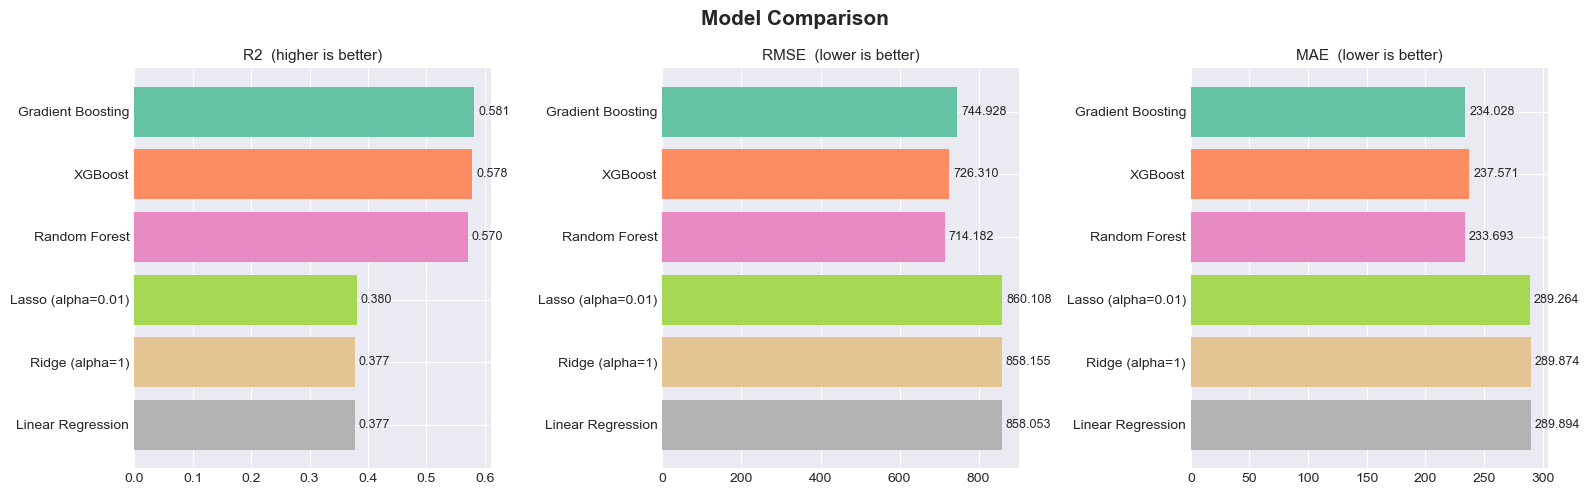

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison', fontsize=15, fontweight='bold')
colors = plt.cm.Set2(np.linspace(0, 1, len(metrics_df)))

for ax, metric, note in zip(
    axes,
    ['R2','RMSE','MAE'],
    ['higher is better','lower is better','lower is better']
):
    bars = ax.barh(metrics_df['Model'], metrics_df[metric], color=colors)
    ax.set_title(f'{metric}  ({note})', fontsize=11)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

Best Model : Gradient Boosting
R²         : 0.5814
RMSE       : 744.93
MAPE       : 1508923206.50%


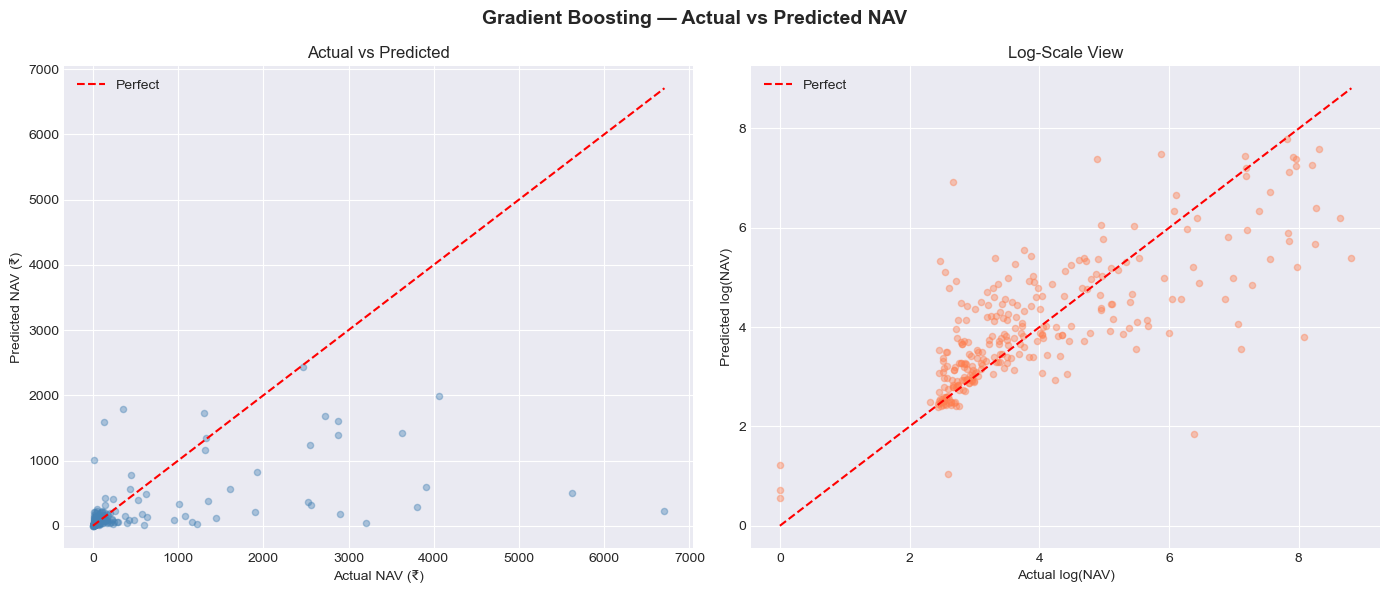

In [21]:
best = max(results, key=lambda r: r['R2'])
print(f'Best Model : {best["Model"]}')
print(f'R²         : {best["R2"]:.4f}')
print(f'RMSE       : {best["RMSE"]:.2f}')
print(f'MAPE       : {best["MAPE"]:.2f}%')

y_pred_log = best['pred_log']
y_pred_nav = np.expm1(y_pred_log)
y_true_nav = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'{best["Model"]} — Actual vs Predicted NAV', fontsize=14, fontweight='bold')

# Scatter
axes[0].scatter(y_true_nav, y_pred_nav, alpha=0.4, color='steelblue', s=20)
lims = [0, max(y_true_nav.max(), y_pred_nav.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Actual NAV (₹)'); axes[0].set_ylabel('Predicted NAV (₹)')
axes[0].set_title('Actual vs Predicted'); axes[0].legend()

# Log-scale scatter
axes[1].scatter(y_test, y_pred_log, alpha=0.4, color='coral', s=20)
lims2 = [y_test.min(), y_test.max()]
axes[1].plot(lims2, lims2, 'r--', lw=1.5, label='Perfect')
axes[1].set_xlabel('Actual log(NAV)'); axes[1].set_ylabel('Predicted log(NAV)')
axes[1].set_title('Log-Scale View'); axes[1].legend()

plt.tight_layout(); plt.show()

5-Fold CV R² — Gradient Boosting
  Scores : [0.4962 0.5593 0.6302 0.5861 0.6898]
  Mean   : 0.5923
  Std    : 0.0653


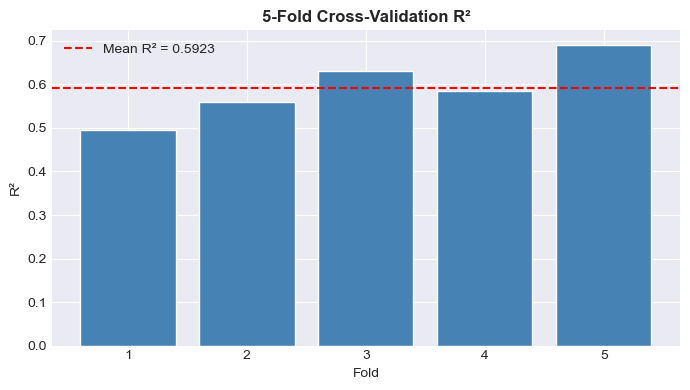

In [23]:
best_model = best['fitted']
linear_models = ('Linear Regression','Ridge (alpha=1)','Lasso (alpha=0.01)')
X_cv = X_train_sc if best['Model'] in linear_models else X_train

cv_scores = cross_val_score(best_model, X_cv, y_train, cv=5, scoring='r2')
print(f'5-Fold CV R² — {best["Model"]}')
print(f'  Scores : {np.round(cv_scores, 4)}')
print(f'  Mean   : {cv_scores.mean():.4f}')
print(f'  Std    : {cv_scores.std():.4f}')

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean R² = {cv_scores.mean():.4f}')
plt.xlabel('Fold'); plt.ylabel('R²')
plt.title('5-Fold Cross-Validation R²', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

In [24]:
new_fund = {
    'Morning star rating'  : 4,
    'Value Research rating': 3,
    '1_month_return'       : 5.5,     # %
    '1_year_return'        : 38.0,    # %
    '3_year_return'        : 22.0,    # %
    'AUM_cr'               : 3000.0,  # crores
    'Min_Investment'       : 500.0,   # Rs.
    'Risk_encoded'         : 5,       # 1=Low ... 6=Very High
    'AMC_encoded'          : 10,
    'Return_Risk_Ratio'    : 38.0 / 5,
}
# One-hot: set the right category to 1, rest to 0
for col in cat_dummies:
    new_fund[col] = 0
# e.g. 'Cat_Equity', 'Cat_Hybrid', 'Cat_Other' — check cat_dummies list above
if 'Cat_Equity' in cat_dummies:
    new_fund['Cat_Equity'] = 1

new_X = np.array([[new_fund[f] for f in FEATURES]])
if best['Model'] in linear_models:
    new_X = scaler.transform(new_X)

log_pred = best_model.predict(new_X)[0]
nav_pred = np.expm1(log_pred)

print('=' * 44)
print(f'  Model Used         : {best["Model"]}')
print(f'  Predicted log(NAV) : {log_pred:.4f}')
print(f'  Predicted NAV (₹)  : {nav_pred:.2f}')
print('=' * 44)

  Model Used         : Gradient Boosting
  Predicted log(NAV) : 4.8670
  Predicted NAV (₹)  : 128.93


In [25]:
import joblib

joblib.dump(best['fitted'], 'best_nav_model.pkl')
joblib.dump(scaler,         'nav_scaler.pkl')

print("Model saved  -> 'best_nav_model.pkl'")
print("Scaler saved -> 'nav_scaler.pkl'")

Model saved  -> 'best_nav_model.pkl'
Scaler saved -> 'nav_scaler.pkl'
